In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from typing import Any, Callable, NamedTuple
from pathlib import Path
from random import choices

import numpy as np
from numpy.typing import NDArray
import pandas as pd
from bisect import bisect_left, bisect_right

from bloodmoon.io import simulation_files
from bloodmoon.coords import shift2angle, equatorial2shift
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode
from bloodmoon.mask import variance, snratio
from bloodmoon.optim import model_shadowgram

import darksun as ds
from darksun.types import Tag, LogEntry
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.utils import savefig_to

In [3]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"
#DATA_FITS: str = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

ANALYSIS_ID: str = "singleCAM_iros_upx2upy1_newOptimiser"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

In [ ]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)

wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

In [2]:
class Source(NamedTuple):
    """
    Local frame coded-mask camera angular coordinates.

    Args:
        ID (str): Source name.
        angle_x (float): Angular coord along x-axis [deg]
        angle_y (float): Angular coord along y-axis [deg]
        flux (float): Source incoming flux [Crab]
    """
    ID: str
    angle_x: float
    angle_y: float
    flux: float


def simul_coords(
    n_sources: int,
    fov: tuple[int | float, int | float] = (-45, 45),
) -> tuple[tuple[float, float], ...]:
    """Simulates sources camera local-frame angular coords."""
    txs, tys = tuple(np.random.uniform(*fov, n_sources) for _ in range(2))
    return tuple((tx, ty) for tx, ty in zip(txs, tys))


def simul_fluxes(
    n_sources: int,
    f_min: int | float,
    f_max: int | float,
    pdf: Callable[[NDArray], NDArray] | None = None,
    sampling: int = 10_000,
) -> tuple[float, ...]:
    """Simulates sources fluxes in [Crab] (also from custom PDF, if given)."""
    f: NDArray = np.linspace(f_min, f_max, sampling + 1)
    weights: NDArray | None = pdf(f) if pdf is not None else None
    return tuple(choices(f, weights, k=n_sources))


def get_sources(
    coords: tuple[tuple[float, float], ...],
    fluxes: tuple[float, ...],
    IDs: tuple[str, ...] | None = None,
) -> tuple[Source, ...]:
    """
    Simulates the sky-field sources with IDs from input
    fluxes and camera local-frame angular coords values.
    """
    if not len(coords) == len(fluxes):
        raise ValueError("Input coords and fluxes tuples must have same length.")
    if IDs is None:
        IDs = tuple(f's{idx}' for idx in range(len(coords)))
    
    sources: tuple[Source, ...] = tuple(
        Source(id_, thx, thy, f) for id_, (thx, thy), f in zip(IDs, coords, fluxes)
    )
    return sources


# pdf(flux) in f_min, f_max
# compute cumulative and normalise in [0, 1]
# N numbers in [0, 1] (sources)
# scipy.interpolate.grid_data()

In [ ]:
def maxwellian(x: NDArray, a: float) -> NDArray:
    """Maxwell-Boltzmann prob. distribution function."""
    c = np.sqrt(2.0 / np.pi) / np.pow(a, 3)
    t = - np.pow(x / a, 2) / 2.0
    return c * np.pow(x, 2) * np.exp(t)


def flux_pdf(
    *args,
    **kwargs,
) -> Callable[[NDArray], NDArray]:
    """Initialises a sky-field sources flux PDF in [Crab]."""
    
    def pdf(flux: NDArray) -> NDArray:
        """Sky-field sources flux distribution in [Crab]."""
        ...
    
    return pdf

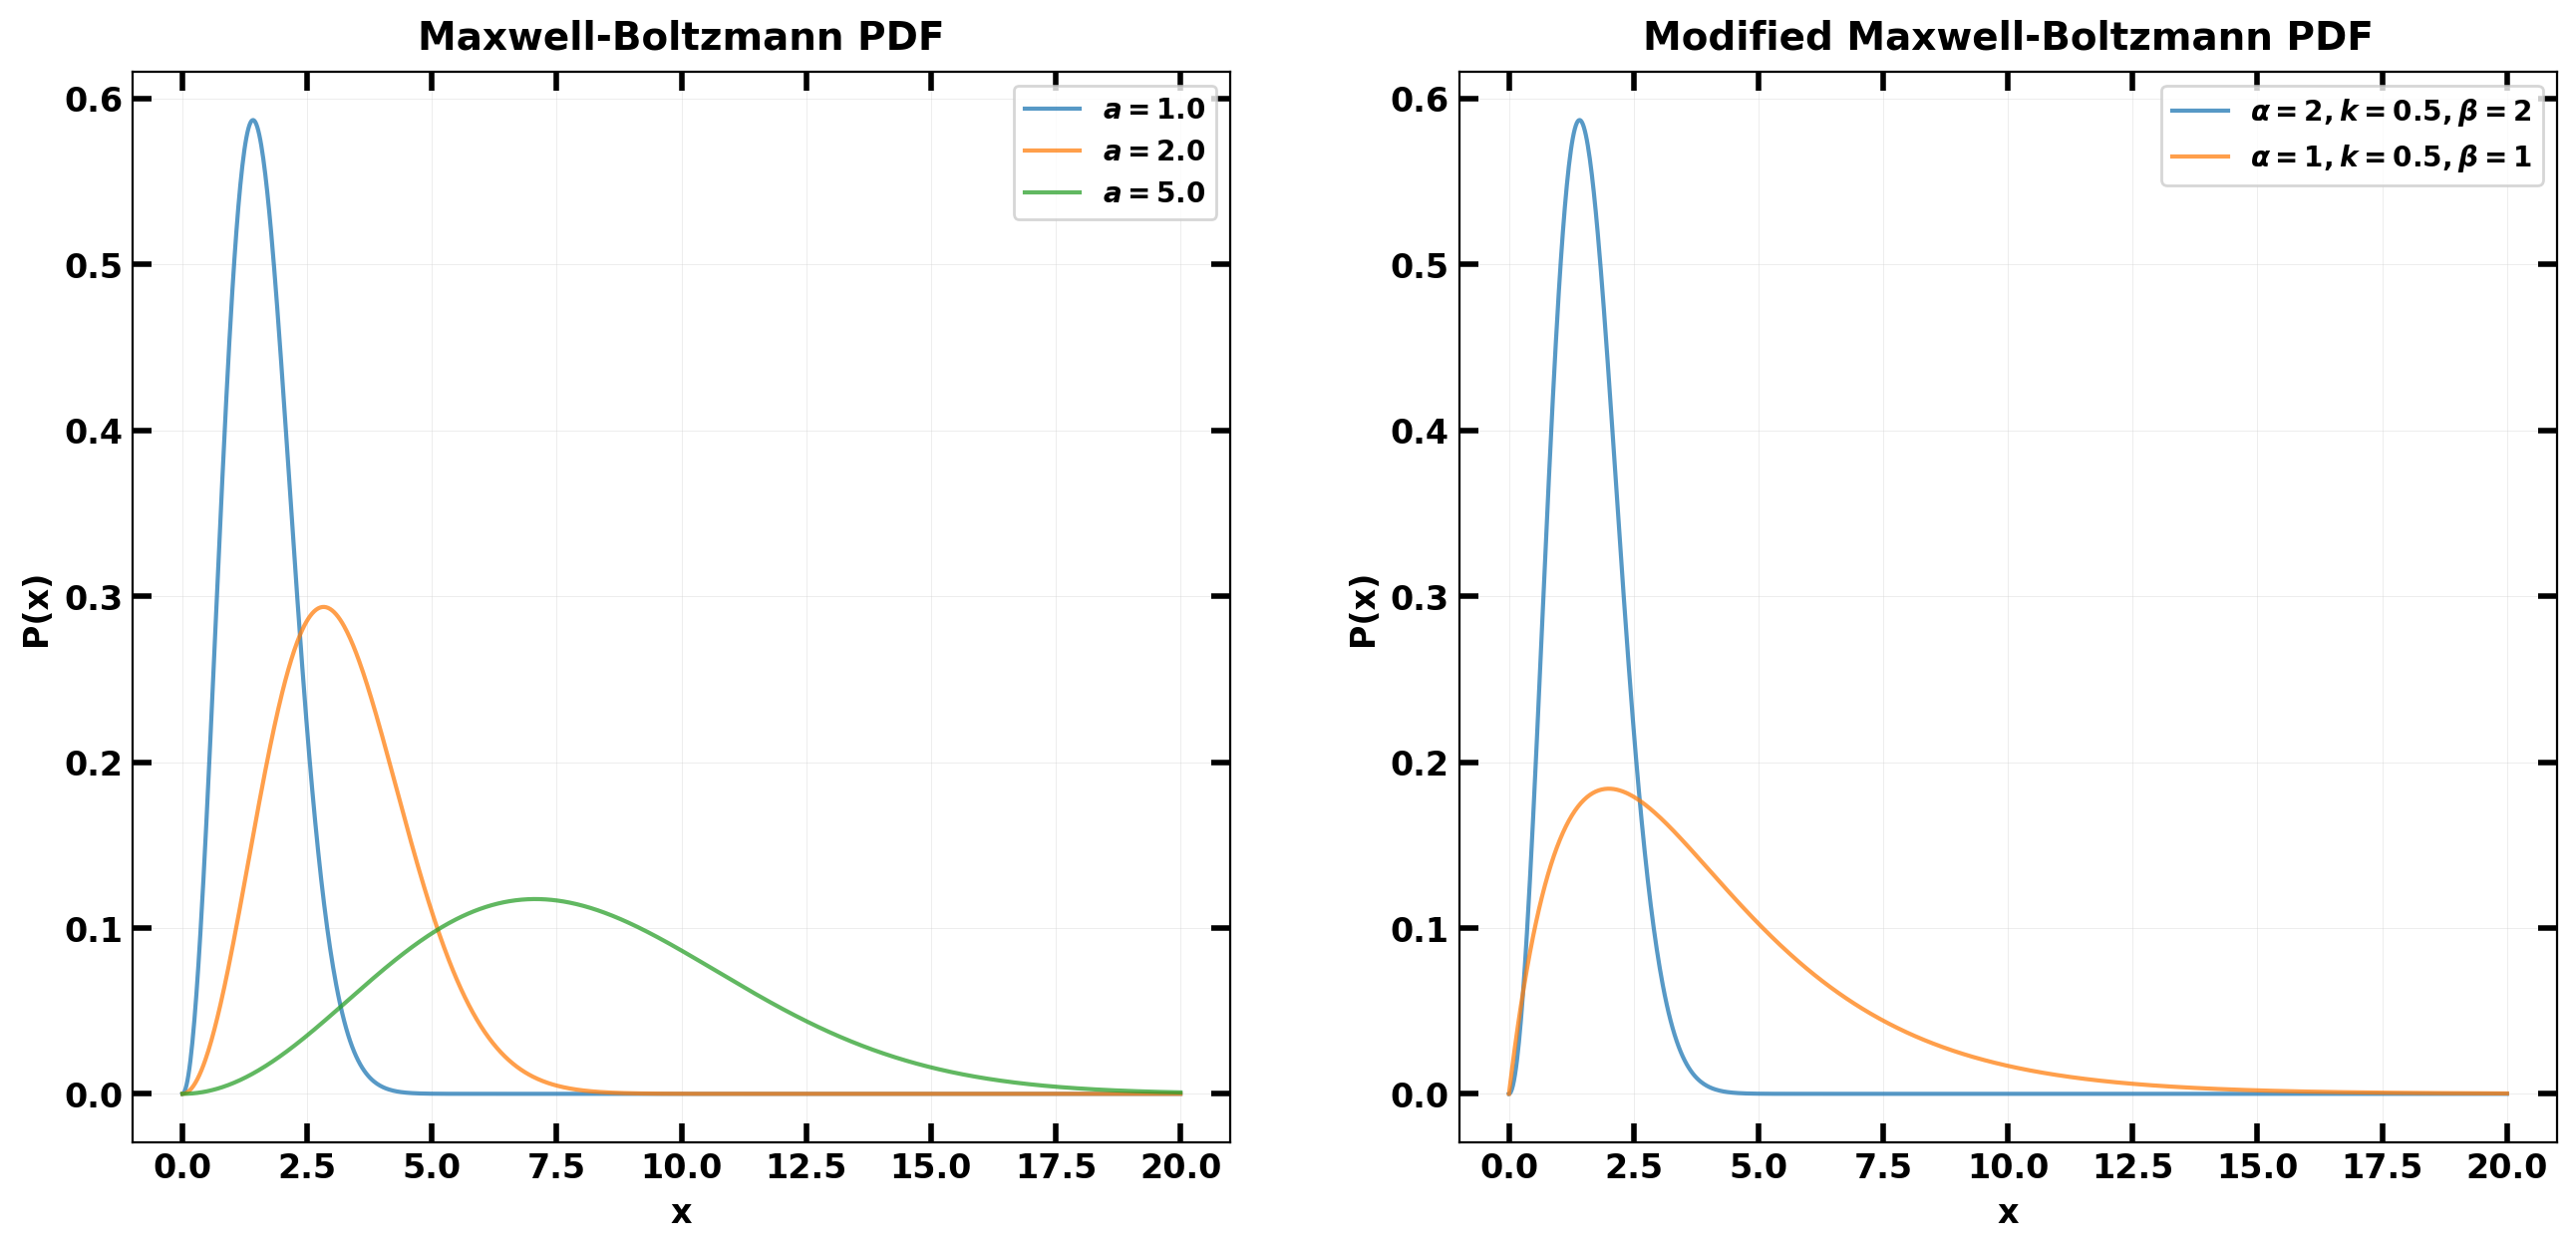

In [26]:
from scipy.special import gamma

def mod_maxwellian(
    x: NDArray,
    alpha: float,
    k: float,
    beta: float,
) -> NDArray:
    """Modified Maxwell-Boltzmann prob. distribution function."""
    f = (alpha + 1) / beta
    A = beta * np.pow(k, f) / gamma(f)
    t = - k * np.pow(x, beta)
    return A * np.pow(x, alpha) * np.exp(t)


x = np.linspace(0, 20, 1001)
as_ = (1.0, 2.0, 5.0)

maxwell = ds.map4plot(
    arrs=tuple(maxwellian(x, a) for a in as_),
    title='Maxwell-Boltzmann PDF',
    x=x,
    labels=tuple(f'$a = {a}$' for a in as_),
    ylabel='P(x)',
    xlabel='x',
)

# factors: tuple(alpha, k, beta)
factors = (
    (2, 0.5, 2),
    (1, 0.5, 1),
)
fs_ = tuple(
    mod_maxwellian(x, alpha, k, beta) for (alpha, k, beta) in factors
)
labels_ = tuple(
    f'$\\alpha={alpha}, k={k}, \\beta={beta}$'
    for (alpha, k, beta) in factors
)


mod_maxwell = ds.map4plot(
    arrs=fs_,
    title='Modified Maxwell-Boltzmann PDF',
    x=x,
    labels=labels_,
    ylabel='P(x)',
    xlabel='x',
)

ds.plot(
    dmaps=(maxwell, mod_maxwell),
    ncols=2,
)

In [ ]:
u_ref = 1.0
u = 10.0


a1 = 1.0
print(maxwellian(u_ref, a1), maxwellian(u, a1))

a2 = 1.0
beta2 = 1.5

print(mod_maxwellian(u_ref, a2, beta2), mod_maxwellian(u, a2, beta2))

In [ ]:
assert False

In [ ]:
simul_coords(5)

((np.float64(26.603629054573958), np.float64(24.4180098128936)),
 (np.float64(-26.834552059583878), np.float64(-24.07495782671586)),
 (np.float64(10.18353494429141), np.float64(-23.698971508937944)),
 (np.float64(7.2634635500122755), np.float64(-12.68968060815147)),
 (np.float64(-23.898695678705614), np.float64(-2.1004561698284476)))

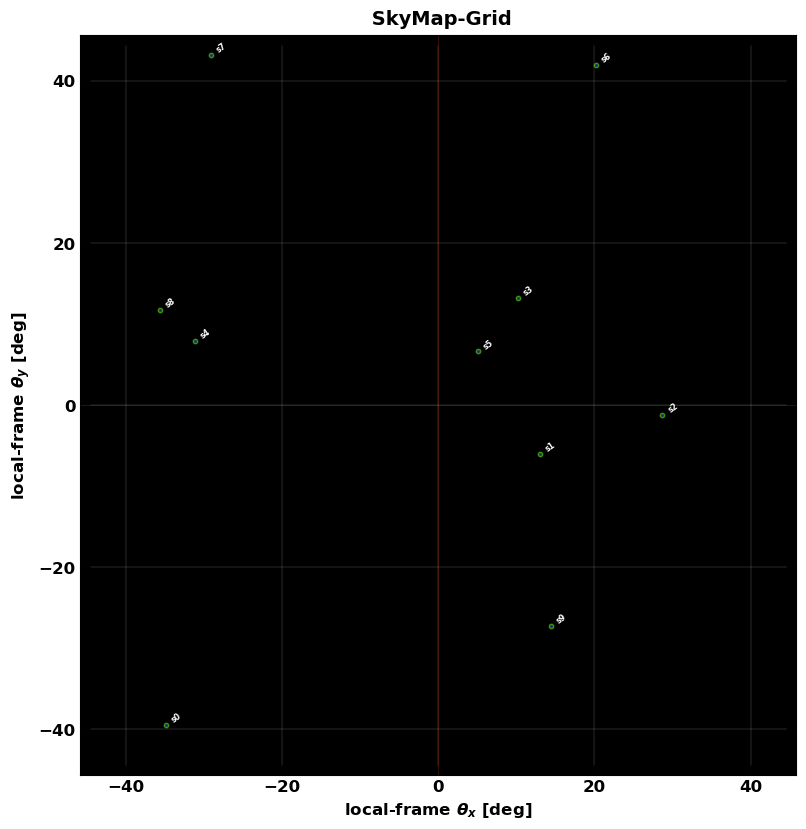

In [ ]:
n_sources: int = 10

sources: tuple[Source, ...] = simul_sources(n_sources)

params: tuple[LogEntry, ...] = (
    LogEntry('ID', 'A20', ''),
    LogEntry('angle_x', 'f8', 'deg'),
    LogEntry('angle_y', 'f8', 'deg'),
)
log: Log = ds.create_log(params)
log.add_entry_values('ID', [s.ID for s in sources])
log.add_entry_values('angle_x', [s.angle_x for s in sources])
log.add_entry_values('angle_y', [s.angle_y for s in sources])


SAVE_TO: str = '/mnt/d/PhD_AASS/Coding/Images_fits'
ds.skyfield_map(log, wfm, show_IDs=True, save_to=savefig_to(SAVE_TO, 'skymap', overwrite=True))

In [ ]:
assert False

## **Testing LEM-X pointing**

CAM1H
  Crab Source Position in the camera local-frame coords
  - shifts: (-52.55320588166768, -56.199841769251)
  - angles: (np.float64(-14.510818374736035), np.float64(-15.470935671066176))
  - RA - DEC: CoordEquatorial(ra=83.6332015991211, dec=22.014499664306626)
  - CAM pointings: {'z': CoordEquatorial(ra=65.6737015953277, dec=35.6486362123488), 'x': CoordEquatorial(ra=257.33165649948, dec=53.7838910823791)}
  - Wanted CAM pointings: CoordEquatorial(ra=83.1078519664901, dec=21.540083357047777)



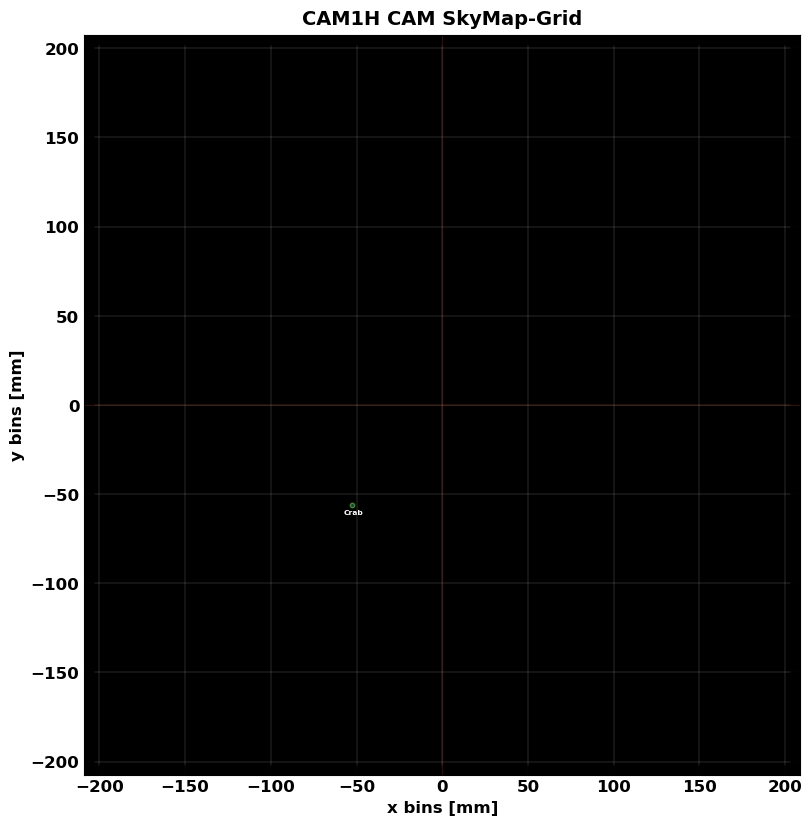

In [ ]:
from pathlib import Path

from bloodmoon.coords import equatorial2shift, shift2angle, shift2equatorial, angle2shift
from bloodmoon.mask import codedmask, count, decode

import darksun as ds
from darksun.types import LogEntry
from darksun.show import skyfield_map


# setup mask and data
base_path = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
skyfield = 'Crab/PointingTests'
mask_FITS = 'wfm_mask_NTHT_20250725.fits'
data_FITS = 'test_camera_tilt'
filepath = f'{base_path}/{skyfield}/{data_FITS}'

UPX, UPY = 1, 1
wfm = codedmask(f'{base_path}/{mask_FITS}', UPX, UPY)

CrabRA = 83.6332015991211
CrabDEC = 22.0144996643066
cameras = tuple(p.name for p in Path(filepath).glob('*cam1h*') if p.is_dir())


for camID in cameras:
    sdlA = ds.get_data(f'{filepath}/{camID}/{data_FITS}_{camID}_detected.fits')
    detector, _ = count(wfm, sdlA.DLdata)
    sky = decode(wfm, detector)
    shiftx, shifty = equatorial2shift(sdlA, wfm, CrabRA, CrabDEC)
    thetax, thetay = tuple(map(lambda x: shift2angle(wfm, x), (shiftx, shifty)))
    print(
        f'{camID.upper()}\n'
        f'  Crab Source Position in the camera local-frame coords\n'
        f'  - shifts: {shiftx, shifty}\n'
        f'  - angles: {thetax, thetay}\n'
        f'  - RA - DEC: {shift2equatorial(sdlA, wfm, shiftx, shifty)}\n'
        f'  - CAM pointings: {sdlA.pointings}\n'
        f'  - Wanted CAM pointings: {shift2equatorial(
            sdlA, wfm, angle2shift(wfm, -15.0), angle2shift(wfm, -15.0),
        )}\n'
    )

    # show source position in skymap
    params = (
        LogEntry('ID', '20A', ''), LogEntry('shift_x', 'D', 'mm'), LogEntry('shift_y', 'D', 'mm'),
    )
    source_log = ds.create_log(
        params=params,
        name=f'{camID} CAM'
    )
    source_log.update(tuple((p.entry, val) for p, val in zip(params, ('Crab', shiftx, shifty))))
    skyfield_map(
        log=source_log,
        camera=wfm,
    )